# Data-Preprocesing

### Plot Style Setup

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.pylab as mpl
from matplotlib import cm
import matplotlib.colors as mcolors
from nptdms import TdmsFile
import time
import os

# Initialize Matplotlib style for plotting.
def plot_init():
    mpl.rcParams['lines.linewidth'] = 1
    mpl.rcParams['axes.linewidth'] = 1
    mpl.rcParams['axes.labelsize'] = 22
    mpl.rcParams['axes.titlesize'] = 22
    mpl.rcParams['xtick.labelsize'] = 16
    mpl.rcParams['ytick.labelsize'] = 16
    mpl.rcParams['xtick.major.size'] = 5 
    mpl.rcParams['xtick.major.width'] = 1  
    mpl.rcParams['ytick.major.size'] = 5
    mpl.rcParams['ytick.major.width'] = 1
    mpl.rcParams['axes.unicode_minus']=False       
plot_init()

### TDMS Loading and logG Conversion

In [2]:
# Input: a TDMS file containing only the voltage channel.
# Output: converted conductance trace
def load_tdms(file_name):
    # # Instrument calibration parameter
    a = 2.0055  
    b = -13.891
    # Default BJ bias voltage (V)
    bias = 0.1  
    G0 = 77.6e-6  

    tdms_file = TdmsFile.read(file_name)
    for group in tdms_file.groups():
        group_name = group.name
        for channel in group.channels():
            channel_name = channel.name
            # Access numpy array of data for channel:
            data_V = channel[:]

    logI = a * data_V + b 
    I = 10 ** (logI)

    G = I / bias
    logG = np.log10(G / G0)
    
    return logG

### Trace Segmentation

In [3]:
# Input: continuous conductance signal.
# Output: segmented single-trace conductance curves.
# Total trace length = left_shift + right_shift.
def cut_traces(logG, left_shift, right_shift):
    gap_threshold = 500  # Half-cycle length must be > gap_threshold
    aboveIdx = np.where(logG > -0.1)[0]  
    aboveIdxDiff = np.diff(aboveIdx)
    gapIdxIdx = np.where(aboveIdxDiff > gap_threshold)[0]  
    gapIdx = aboveIdx[gapIdxIdx]
    
    right_shift = right_shift
    left_shift = left_shift
    full_length = left_shift + right_shift

    singleTrace = np.zeros((1, full_length))
    for i, idx in enumerate(gapIdx):
        # Skip if the window goes out of bounds
        if idx < left_shift or idx + right_shift > logG.shape[0]: continue 
            
        # Remove overlapping traces
        if i > 0 and i < gapIdx.shape[0] - 1: 
            if gapIdx[i] + right_shift > gapIdx[i+1] or gapIdx[i] - left_shift < gapIdx[i-1]: continue
                
        curve = logG[idx - left_shift:idx + right_shift].reshape(1, -1)
        
        # Filter unstable traces
        if curve.reshape(-1)[1401:].max() > 0: continue  
        singleTrace = np.concatenate([singleTrace, curve])
    return singleTrace[1:]

### Batch Processing

In [4]:
st = time.time()
file_prefix = r'../data/Raw Data/STM3-'
file_suffix = '.tdms'
left_shift, right_shift = 250, 1250
full_length = left_shift + right_shift
single_curve = np.zeros((1, full_length))

# Batch-load TDMS files
for name in range(1, 11):
    path = file_prefix + str(name) + file_suffix
    if not os.path.exists(path): 
        print(path, 'not exist!')
        continue
    group_logG = load_tdms(path)
    group_traces = cut_traces(group_logG, left_shift=left_shift, right_shift=right_shift)
    print('group ' + str(name) + ' has {} traces'.format(group_traces.shape[0]))
    single_curve = np.concatenate([single_curve, group_traces])
ed = time.time()
time_comsumed = (ed - st) / 60.0
print(f'Processing completed. Total time: {time_comsumed:.3f} minutes')

group 22 has 326 traces
group 23 has 335 traces
group 24 has 323 traces
group 25 has 303 traces
group 26 has 317 traces
group 27 has 301 traces
group 28 has 300 traces
group 29 has 306 traces
group 30 has 294 traces
group 31 has 306 traces
Processing completed. Total time: 0.029 minutes


In [5]:
cur_data = single_curve[1:]  # all traces
cur_data.shape 

(3111, 1500)

### Parameter Setup

In [6]:
# Parameters 
SAMPLE_RATE = 20000.0       # Sampling rate (Hz)
PULLING_SPEED = 25.0        # Electrode pulling speed (nm/s)

ANCHOR_INDEX = 250          # Alignment anchor index (0 nm)
TRACE_LENGTH = 1500         # Total length per trace

LENGTH_THRESHOLD = 1.0      # Length filter threshold (nm)
G_UPPER = -0.3              # Upper bound of analysis range (logG)
G_LOWER = -5.5              # Lower bound of analysis range (logG)

# Compute physical distance axis (x-axis)
time_indices = np.arange(TRACE_LENGTH) - ANCHOR_INDEX
distance_axis = time_indices * (1 / SAMPLE_RATE) * PULLING_SPEED

print("Parameter check:")
print(f" - Pulling speed: {PULLING_SPEED} nm/s")
print(f" - X-axis range: {distance_axis[0]:.2f} nm to {distance_axis[-1]:.2f} nm")
print(f" - Index at 0 nm: {ANCHOR_INDEX}")

Parameter check:
 - Pulling speed: 25.0 nm/s
 - X-axis range: -0.31 nm to 1.56 nm
 - Index at 0 nm: 250


### Compute plateau length

In [7]:
# Compute plateau length
plateau_lengths = []
valid_indices = []
empty_indices = []

# Distance per sampling point (nm) 
dz_per_point = PULLING_SPEED / SAMPLE_RATE 

for i, trace in enumerate(cur_data):
    # Only analyze the segment after 0 nm (anchor)
    # Select points within the conducctance range [G_LOWER, G_UPPER]
    # and restrict to index >= ANCHOR_INDEX 
    mask = (trace <= G_UPPER) & (trace >= G_LOWER) & (np.arange(TRACE_LENGTH) >= ANCHOR_INDEX)
    indices = np.where(mask)[0]
    
    if len(indices) > 1:
        # Plateau span
        span_points = indices[-1] - indices[0]
        length_nm = span_points * dz_per_point
    else:
        length_nm = 0.0
    
    plateau_lengths.append(length_nm)
    
    if length_nm > LENGTH_THRESHOLD:
        valid_indices.append(i)
    else:
        empty_indices.append(i)

plateau_lengths = np.array(plateau_lengths)
valid_traces = cur_data[valid_indices]
empty_traces = cur_data[empty_indices]

print(f"Filtering summary: Total={len(cur_data)}, Valid={len(valid_traces)}, Empty={len(empty_traces)}")
print(f"Junction formation probability (JFP): {len(valid_traces)/len(cur_data)*100:.2f}%")

Filtering summary: Total=3111, Valid=1391, Empty=1720
Junction formation probability (JFP): 44.71%


### Plotting

In [8]:
# 2D Histogram
def plot_2d_map(ax, traces, cmx, dist_axis, title):
    if len(traces) == 0: return
    
    # Build X/Y arrays for hist2d
    # X-axis: displacement
    X = np.tile(dist_axis, (len(traces), 1)).flatten()
    # Y-axis: conductance
    Y = traces.flatten()
    
    # Histogram range
    x_min, x_max = distance_axis[0], distance_axis[-1]
    
    h = ax.hist2d(X, Y, bins=200, 
                  range=[[x_min, x_max], [-7, 1]], 
                  cmap='bwr', density=True, cmin=0.05, cmax=cmx, norm=mcolors.LogNorm())
    
    ax.set_title(f"{title}\n(N={len(traces)})", fontsize=14)
    ax.set_xlabel("Relative Displacement (nm)", fontsize=12)
    ax.set_ylabel("Log(G/G0)", fontsize=12)
    
    # Reference lines
    ax.axvline(0, color='white', linestyle='--', linewidth=1, alpha=0.7) # 0nm 
    ax.axhline(G_UPPER, color='white', linestyle=':', linewidth=0.5)
    ax.axhline(G_LOWER, color='white', linestyle=':', linewidth=0.5)
    
    # Reference lines
    ax.set_xlim(-0.5, 2.0)
    ax.set_ylim(-6, 1.0)

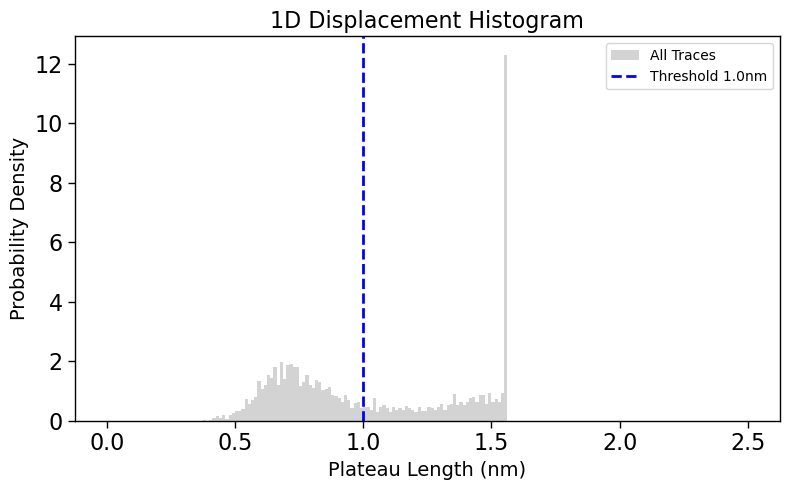

In [9]:
# 1D plateau-length distribution
plt.figure(figsize=(8, 5))
plt.hist(plateau_lengths, bins=200, range=(0, 2.5), color='lightgray', label='All Traces', density=True)
plt.axvline(LENGTH_THRESHOLD, color='blue', linestyle='--', linewidth=2, label=f'Threshold {LENGTH_THRESHOLD}nm')
plt.xlabel('Plateau Length (nm)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.title('1D Displacement Histogram', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

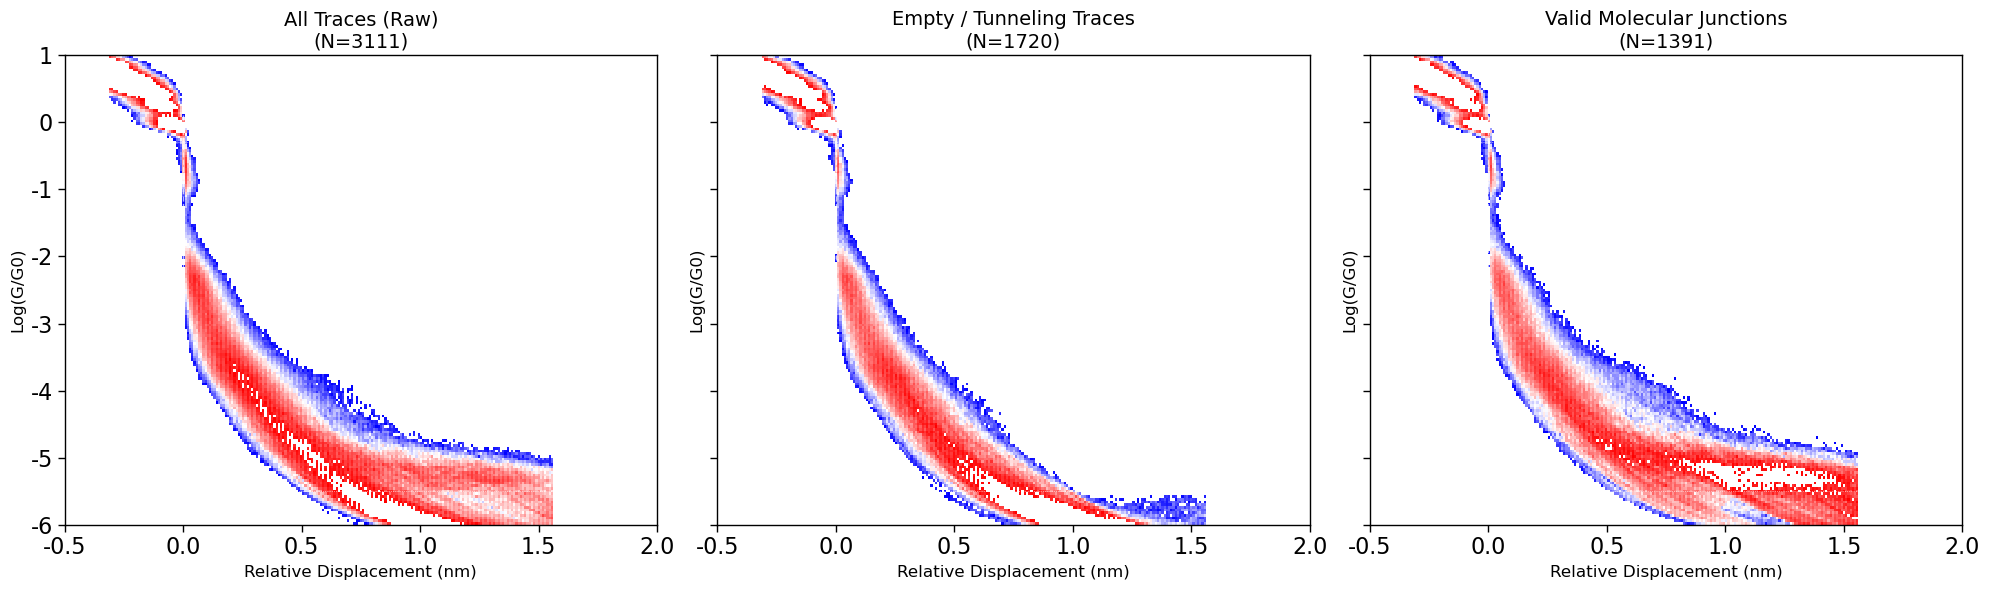

In [10]:
# 2D conductance–displacement histograms (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

# All traces
plot_2d_map(axes[0], cur_data, 0.5, distance_axis, "All Traces (Raw)")

# Empty / tunneling traces
plot_2d_map(axes[1], empty_traces, 0.6, distance_axis, "Empty / Tunneling Traces")

# Valid molecular junction traces
plot_2d_map(axes[2], valid_traces, 0.6, distance_axis, "Valid Molecular Junctions")

plt.tight_layout()
plt.show()